In [21]:
import numpy as np
from deepface import DeepFace
from deepface.modules import verification
from deepface.models.FacialRecognition import FacialRecognition
import cv2

2025-02-25 16:21:22.221686: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-25 16:21:22.257004: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-25 16:21:22.257725: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-25 16:21:22.890552: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [45]:
model_name = "Facenet"

model: FacialRecognition = DeepFace.build_model(task="facial_recognition", model_name=model_name)

target_size = model.input_shape

In [9]:
img1 = DeepFace.extract_faces('/home/server-iss-mbkm/project/project_student_detection/student_detection_dataset/raw_object/test.jpg')


In [38]:
print(len(img1))

11


In [40]:
len(img1[0]['face'])

46

In [1]:
import os
from src.components.config import data_config
from src.components.feature_extraction import FeatureExtraction

db_path:str = data_config.database_path

file_list = [f for f in os.listdir(db_path) if os.path.isfile(os.path.join(db_path, f))]
file_list

2025-02-24 11:00:48.208732: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-24 11:00:48.245710: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-24 11:00:48.246791: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-24 11:00:48.885529: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


['10423039.jpg',
 '20422053.jpg',
 '0423014.jpg',
 '10423017.jpg',
 '10923093.jpg',
 '30724061.jpg',
 '10423031.jpg',
 '10423024.jpg',
 '20422065.jpg',
 '10423007.jpg',
 '10423014.jpg',
 '20421069.jpg',
 '30724049.jpg',
 '20420012.jpg',
 '20421053.jpg',
 '10924117.jpg',
 '0422058.jpg',
 '10423018.jpg',
 '0424026.jpg',
 '10423028.jpg',
 '30724051.jpg',
 '10924115.jpg']

In [3]:
obj = FeatureExtraction()
obj_dict = obj.images_store()
obj_dict

Processing 10423039.jpg...
Processing 20422053.jpg...
Processing 0423014.jpg...
Processing 10423017.jpg...
Processing 10923093.jpg...
Processing 30724061.jpg...
Processing 10423031.jpg...
Processing 10423024.jpg...
Processing 20422065.jpg...
Processing 10423007.jpg...
Processing 10423014.jpg...
Processing 20421069.jpg...
Processing 30724049.jpg...
Processing 20420012.jpg...
Processing 20421053.jpg...
Processing 10924117.jpg...
Processing 0422058.jpg...
Processing 10423018.jpg...
Processing 0424026.jpg...
Processing 10423028.jpg...
Processing 30724051.jpg...
Processing 10924115.jpg...


{'10423039.jpg': array([[[ 10,  15,  18],
         [  8,  13,  16],
         [  7,  11,  16],
         ...,
         [ 10,  15,  18],
         [ 12,  17,  20],
         [ 12,  17,  18]],
 
        [[  8,  13,  16],
         [  7,  12,  15],
         [  6,  10,  15],
         ...,
         [ 11,  16,  19],
         [ 13,  18,  21],
         [ 12,  17,  18]],
 
        [[  7,  12,  15],
         [  7,  12,  15],
         [  7,  11,  16],
         ...,
         [ 12,  17,  20],
         [ 13,  18,  21],
         [ 13,  18,  19]],
 
        ...,
 
        [[175, 187, 197],
         [178, 190, 200],
         [181, 193, 203],
         ...,
         [154, 166, 172],
         [151, 163, 169],
         [147, 159, 163]],
 
        [[173, 187, 199],
         [174, 188, 200],
         [177, 191, 203],
         ...,
         [156, 168, 174],
         [151, 163, 169],
         [146, 158, 162]],
 
        [[173, 187, 199],
         [174, 188, 200],
         [176, 190, 202],
         ...,
         [15

In [39]:
len(obj_dict['10423039.jpg'])

186

In [53]:

tmp1 = img1[0]["face"]
tmp1 = cv2.resize(tmp1,target_size)
tmp1 = np.expand_dims(tmp1, axis=0)  # to (1, 224, 224, 3)
tmp1_representation = model.forward(tmp1)

tmp2 = img1[0]["face"] #obj_dict['10423039.jpg']
tmp2 = cv2.resize(tmp2, target_size)
tmp2  = np.expand_dims(tmp2, axis=0)
tmp2_representation = model.forward(tmp2)

tmp1_representation = np.array(tmp1_representation)
tmp2_representation  = np.array(tmp2_representation)

In [54]:
distance_vector = np.square(tmp1_representation - tmp2_representation)
current_distance = np.sqrt(distance_vector.sum())
current_distance 

0.0

In [ ]:
threshold = verification.find_threshold(model_name=model_name, distance_metric="euclidean")
threshold

10

In [7]:
ig = cv2.imread('/home/server-iss-mbkm/project/project_student_detection/student_detection_dataset/raw_object/test.jpg')

In [12]:
for i in range(len(img1)):
    x,y,w,h,_,_ = img1[i]['facial_area'].values()
    cv2.rectangle(ig, (x, y), (x + w, y + h), (0, 255, 0), 2)
cv2.imshow('Cropped', ig)
cv2.waitKey()
cv2.destroyAllWindows() 

In [ ]:

result = DeepFace.verify(np.array(img1[0]['face']), np.array(obj_dict['10423039.jpg']), model_name="VGG-Face", detector_backend="opencv", distance_metric="cosine", enforce_detection=True, align=True, normalization="base")
print(result)

In [18]:
import pandas as pd

df = pd.read_csv('/home/server-iss-mbkm/project/project_student_detection/student_detection_dataset/csv/representation_database.csv')
df

,NIM,value
0,'10423039',"[-0.07198193669319153, -0.5420476794242859, -0..."
1,'20422053',"[1.1730808019638062, -1.012515664100647, -2.91..."
2,'0423014',"[0.2514243721961975, -0.09998102486133575, -0...."
3,'10423017',"[0.8447209596633911, -0.9314258098602295, -0.0..."
4,'10923093',"[-0.6015174388885498, -1.537880539894104, -1.3..."
5,'30724061',"[0.36796835064888, -1.608873963356018, -0.5767..."
6,'10423031',"[-1.3166909217834473, 0.2509569525718689, -1.7..."
7,'10423024',"[0.9647623300552368, -1.547758936882019, -2.35..."
8,'20422065',"[-1.0820685625076294, -2.156827688217163, -1.2..."
9,'10423007',"[-0.3419894874095917, -1.1794686317443848, -0...."


In [ ]:

def read_csv():
        data = []
        with open('/home/server-iss-mbkm/project/project_student_detection/student_detection_dataset/csv/representation_database.csv', newline='') as file: 
            reader = csv.DictReader(file) 
            #return reader
            for row in enumerate(reader):
                data.append(row)
        return data

In [ ]:
db = '/home/server-iss-mbkm/project/project_student_detection/student_detection_dataset/csv/representation_database.csv'
tmp = [-0.07198193669319153, -0.5420476794242859, -0.7786660194396973, -1.5404306650161743, -1.2480131387710571, -0.9233647584915161, -0.18481312692165375, -0.5409640073776245, 0.798850953578949, -0.7959970235824585, 1.0446267127990723, -0.10413222759962082, -0.502007007598877, -1.6706032752990723, 0.4587642550468445, 0.12951259315013885, 2.252561569213867, -0.09482429176568985, 1.1131548881530762, -0.7935344576835632, -0.676630973815918, -0.43492934107780457, -1.5086992979049683, 0.8176430463790894, 1.5876253843307495, 1.3565788269042969, -0.12908747792243958, 1.1390535831451416, -1.0992403030395508, -1.5546191930770874, -1.024282693862915, 0.6701724529266357, -1.274011254310608, -0.25948765873908997, 1.0783815383911133, 1.3500573635101318, -1.3117773532867432, 1.562356948852539, 0.9301109313964844, 0.9436689615249634, -0.34857863187789917, -0.11907754093408585, -1.2861180305480957, -0.183827206492424, 0.39952531456947327, -0.27664753794670105, 0.08544516563415527, -0.04540940374135971, 0.851004958152771, -0.3312906324863434, 0.013990186154842377, 0.3257482051849365, 0.5614323019981384, -1.8764395713806152, 1.5571881532669067, 0.0027939300052821636, -0.07095369696617126, -0.8241850137710571, 1.631895899772644, 0.3453681170940399, 1.2737798690795898, -0.49803727865219116, -0.7901686429977417, -1.4762012958526611, 1.615617275238037, 0.937391996383667, 0.76520174741745, 0.23363374173641205, -0.04179621860384941, -0.05029352009296417, -0.7783759832382202, -0.15337973833084106, -0.006339628249406815, -2.3712880611419678, -0.33908140659332275, 0.3367730975151062, -0.7631367444992065, -0.039171990007162094, -0.5601023435592651, -0.3884217143058777, -0.3166756331920624, -0.2747940421104431, -1.8218830823898315, -0.3108013868331909, 0.41325053572654724, -0.2712003290653229, -1.2179999351501465, -0.7081393003463745, 0.07536382973194122, 1.2265183925628662, 2.2188477516174316, -0.5970045328140259, -0.4411921203136444, -0.28841856122016907, -0.37329891324043274, -0.07032200694084167, 0.7720025777816772, 1.6296160221099854, -0.5200047492980957, 1.329947829246521, 2.3156931400299072, -0.5378004908561707, 0.9882121682167053, -1.0924574136734009, -0.9009541869163513, 1.084000825881958, -0.08165141940116882, 0.9321732521057129, -0.4100872874259949, -0.5333611369132996, -0.11890538781881332, 0.5474570989608765, 0.8771971464157104, -0.6706073880195618, 0.5453605055809021, -0.7991139888763428, -0.8642338514328003, 0.3337922692298889, 1.7420600652694702, 1.8484243154525757, 0.6312607526779175, 0.6714434623718262, -0.9070172309875488, -0.5792810916900635, 0.9147881269454956, -0.6132315397262573, 0.9299461841583252, -1.897474765777588]
res = []
with open('/home/server-iss-mbkm/project/project_student_detection/student_detection_dataset/csv/representation_database.csv', newline='') as file: 
            reader = csv.DictReader(file) 
            for row in enumerate(reader):
                    res.append(distance_calculation(np.array(tmp), eval(row[1]['value'])))
                    print(row[1]['value'])

UFuncTypeError: ufunc 'subtract' did not contain a loop with signature matching types (dtype('float64'), dtype('<U113')) -> None

In [1]:
import csv
import numpy as np

In [2]:
def distance_calculation(img_representation, db_img_representation):
            img_representation = np.array(img_representation)
            db_img_representation = np.array(db_img_representation)
            distance_vector = np.square(img_representation - db_img_representation)
            current_distance = np.sqrt(distance_vector.sum())
            return current_distance

In [5]:
def csv_representation(img_representation, db_representation): #read database representation CSV 
            res = []
            with open(db_representation, newline='') as file: 
                    reader = csv.DictReader(file) 
                    for row in reader:
                        res.append(distance_calculation(img_representation,eval(row['value'])))
            return res

In [6]:
db = '/home/server-iss-mbkm/project/project_student_detection/student_detection_dataset/csv/representation_database.csv'
tmp = [-0.07198193669319153, -0.5420476794242859, -0.7786660194396973, -1.5404306650161743, -1.2480131387710571, -0.9233647584915161, -0.18481312692165375, -0.5409640073776245, 0.798850953578949, -0.7959970235824585, 1.0446267127990723, -0.10413222759962082, -0.502007007598877, -1.6706032752990723, 0.4587642550468445, 0.12951259315013885, 2.252561569213867, -0.09482429176568985, 1.1131548881530762, -0.7935344576835632, -0.676630973815918, -0.43492934107780457, -1.5086992979049683, 0.8176430463790894, 1.5876253843307495, 1.3565788269042969, -0.12908747792243958, 1.1390535831451416, -1.0992403030395508, -1.5546191930770874, -1.024282693862915, 0.6701724529266357, -1.274011254310608, -0.25948765873908997, 1.0783815383911133, 1.3500573635101318, -1.3117773532867432, 1.562356948852539, 0.9301109313964844, 0.9436689615249634, -0.34857863187789917, -0.11907754093408585, -1.2861180305480957, -0.183827206492424, 0.39952531456947327, -0.27664753794670105, 0.08544516563415527, -0.04540940374135971, 0.851004958152771, -0.3312906324863434, 0.013990186154842377, 0.3257482051849365, 0.5614323019981384, -1.8764395713806152, 1.5571881532669067, 0.0027939300052821636, -0.07095369696617126, -0.8241850137710571, 1.631895899772644, 0.3453681170940399, 1.2737798690795898, -0.49803727865219116, -0.7901686429977417, -1.4762012958526611, 1.615617275238037, 0.937391996383667, 0.76520174741745, 0.23363374173641205, -0.04179621860384941, -0.05029352009296417, -0.7783759832382202, -0.15337973833084106, -0.006339628249406815, -2.3712880611419678, -0.33908140659332275, 0.3367730975151062, -0.7631367444992065, -0.039171990007162094, -0.5601023435592651, -0.3884217143058777, -0.3166756331920624, -0.2747940421104431, -1.8218830823898315, -0.3108013868331909, 0.41325053572654724, -0.2712003290653229, -1.2179999351501465, -0.7081393003463745, 0.07536382973194122, 1.2265183925628662, 2.2188477516174316, -0.5970045328140259, -0.4411921203136444, -0.28841856122016907, -0.37329891324043274, -0.07032200694084167, 0.7720025777816772, 1.6296160221099854, -0.5200047492980957, 1.329947829246521, 2.3156931400299072, -0.5378004908561707, 0.9882121682167053, -1.0924574136734009, -0.9009541869163513, 1.084000825881958, -0.08165141940116882, 0.9321732521057129, -0.4100872874259949, -0.5333611369132996, -0.11890538781881332, 0.5474570989608765, 0.8771971464157104, -0.6706073880195618, 0.5453605055809021, -0.7991139888763428, -0.8642338514328003, 0.3337922692298889, 1.7420600652694702, 1.8484243154525757, 0.6312607526779175, 0.6714434623718262, -0.9070172309875488, -0.5792810916900635, 0.9147881269454956, -0.6132315397262573, 0.9299461841583252, -1.897474765777588]

test = csv_representation(tmp, db_representation=db)
print(test)

[0.0, 11.33267012846996, 13.217951692507917, 7.618878317166652, 11.604180708130604, 13.093240508182687, 12.396556905317551, 13.922459786894875, 13.647370478283694, 8.808427122875125, 13.778257809369467, 12.802058828725905, 13.753715690237382, 12.48349136127114, 13.88478806461396, 12.155700881109894, 13.826841470528949, 11.073988284844425, 13.444901465593164, 12.311085908855802, 12.42819681620519, 10.88838384837474]


In [7]:
list = [0]
min(list)

0

In [34]:
import base64
import numpy as np
import cv2
import pandas as pd

image_path = '/home/server-iss-mbkm/project/project_student_detection/student_detection_dataset/raw_object/test.jpg'


with open(image_path, "rb") as image_file:
    image_data = image_file.read()
    base64_image = base64.b64encode(image_data).decode("utf-8") 
print(base64_image)

...


In [41]:
base64_csv = '/home/server-iss-mbkm/project/project_student_detection/student_detection_dataset/csv/base64.csv'

df = pd.DataFrame({"test":"gambar_1", "value":base64_image})
df


ValueError: If using all scalar values, you must pass an index

''
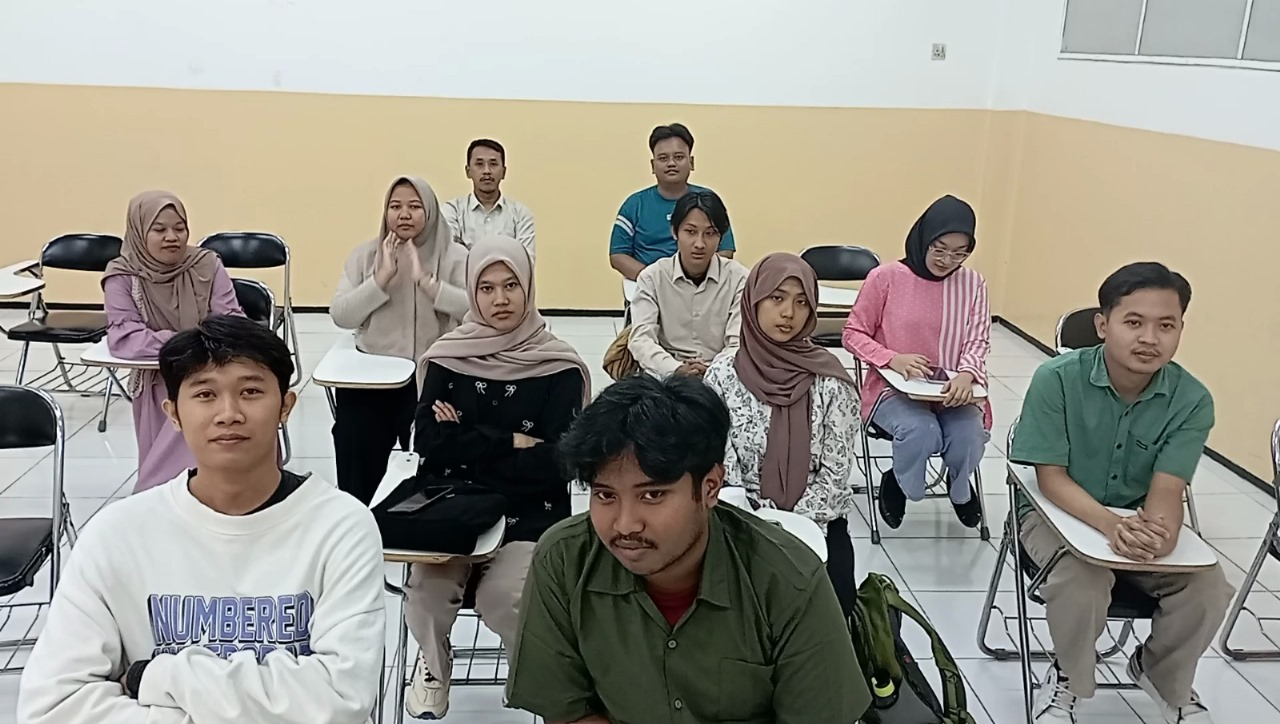

In [37]:
img = f'data:image/.jpg;base64,{base64_image}'
img

In [ ]:
from deepface import DeepFace

In [6]:
test = DeepFace.extract_faces(img)
test

[{'face': array([[[0.97647059, 0.93333333, 0.81568627],
          [0.59215686, 0.55294118, 0.45490196],
          [0.14901961, 0.10588235, 0.03529412],
          ...,
          [0.62745098, 0.59607843, 0.51372549],
          [0.9372549 , 0.89411765, 0.77647059],
          [0.88627451, 0.85098039, 0.69803922]],
  
         [[0.97254902, 0.92941176, 0.81960784],
          [0.4745098 , 0.43529412, 0.3372549 ],
          [0.10588235, 0.05882353, 0.        ],
          ...,
          [0.41960784, 0.37647059, 0.29803922],
          [0.92156863, 0.87843137, 0.76078431],
          [0.89803922, 0.8627451 , 0.70980392]],
  
         [[0.93333333, 0.89019608, 0.78039216],
          [0.35294118, 0.31372549, 0.21568627],
          [0.0627451 , 0.01568627, 0.        ],
          ...,
          [0.31764706, 0.2745098 , 0.20392157],
          [0.83137255, 0.78823529, 0.67843137],
          [0.9372549 , 0.90196078, 0.74901961]],
  
         ...,
  
         [[0.84313725, 0.79607843, 0.64705882],
      

In [18]:
def data_uri_to_cv2_img(uri):
    #encoded_data = uri.split(',')[1]
    nparr = np.frombuffer(base64.b64decode(uri), np.uint8)
    # old (python 2 version):
    # nparr = np.fromstring(encoded_data.decode('base64'), np.uint8)

    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    return img

In [22]:
test = {'images':base64_image,
        "class_id":'2SK1R'}

In [ ]:
test = data_uri_to_cv2_img(test["images"])
cv2.imshow("Image", test)
cv2.waitKey(0) 
cv2.destroyAllWindows()